In [1]:
import cv2 
from skimage.util.shape import view_as_windows
from skimage.feature import graycomatrix, graycoprops 
import numpy as np 
from joblib import Parallel, delayed 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 

PATCH_SIZE = 21


# img1.jpg 


In [2]:
# Reading the image
image_path = 'img1.jpg'
original_image = cv2.imread(image_path)

# Converting the image to grayscale
grayscale_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

# Resizing the image to half of the original size
resized_image = cv2.resize(grayscale_image, (0, 0), fx=0.5, fy=0.5) 


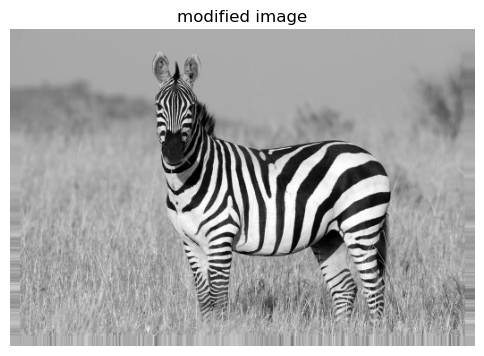

In [3]:
kernel_size = PATCH_SIZE // 2

# Duplicate the first row 10 times and add them above the image
first_row = resized_image[0:1, :]
above_rows = np.tile(first_row, (kernel_size, 1))
img = np.vstack([above_rows, resized_image])

# Duplicate the last row 10 times and add them below the image
last_row = img[-1:, :]
below_rows = np.tile(last_row, (kernel_size, 1))
img = np.vstack([img, below_rows])

# Duplicate the first column 10 times on the left side
left_columns = np.tile(img[:, 0:1], (1, kernel_size))
image = np.concatenate((left_columns, img), axis=1)

# Duplicate the last column 10 times on the right side
right_columns = np.tile(image[:, -1:], (1, kernel_size))
image = np.concatenate((image, right_columns), axis=1)

# Displaying the modified image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray') 
plt.title(f"modified image")
plt.axis('off')
plt.show()

window_shape = (PATCH_SIZE, PATCH_SIZE)
patches = view_as_windows(image, window_shape)

# Number of processes
nprocs = 2 

# Function to compute GLCM properties for a given patch
def compute_glcm_properties(patch):
    glcm = graycomatrix(patch, distances=[5], angles=[0], levels=256,
                        symmetric=True, normed=True)
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0] 
    return dissimilarity, correlation, homogeneity, energy

# Running compute_glcm_properties in parallel 
result = Parallel(n_jobs=nprocs)(
    delayed(compute_glcm_properties)(patches[i, j]) 
    for i in range(patches.shape[0]) 
    for j in range(patches.shape[1])
)

# Separating the result into individual tuples
dissimilarity, correlation, homogeneity, energy = zip(*result)


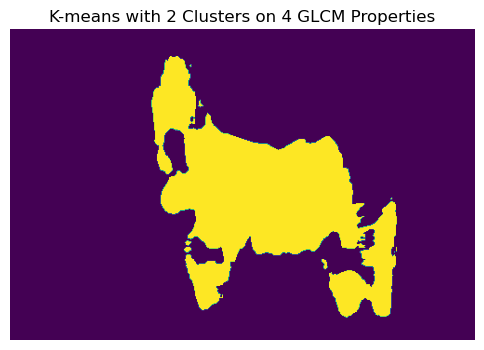

In [4]:
# Converting the GLCM properties to a NumPy array
glcm_properties_array = np.array([dissimilarity, correlation, homogeneity, energy]).T 

# Performing K-means quantization with n_colors=2 on all GLCM properties
n_colors = 2
kmeans = KMeans(n_clusters=n_colors, random_state=0)
kmeans.fit(glcm_properties_array)
labels = kmeans.predict(glcm_properties_array)
quantized_palette = kmeans.cluster_centers_.astype(int)

# Reshaping quantized labels to match the shape of the patches
quantized_labels = labels.reshape(patches.shape[0], patches.shape[1])

# Displaying the quantized image
plt.figure(figsize=(6, 6))
plt.imshow(quantized_labels / (n_colors - 1), cmap='viridis')  # Normalize to [0, 1] for visualization
plt.title(f"K-means with {n_colors} Clusters on 4 GLCM Properties")
plt.axis('off')
plt.show()


# img2.jpg 


In [5]:
# Reading the image
image_path = 'img2.jpg'
original_image = cv2.imread(image_path)

# Converting the image to grayscale
grayscale_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

# Resizing the image to half of the original size
resized_image = cv2.resize(grayscale_image, (0, 0), fx=0.5, fy=0.5) 


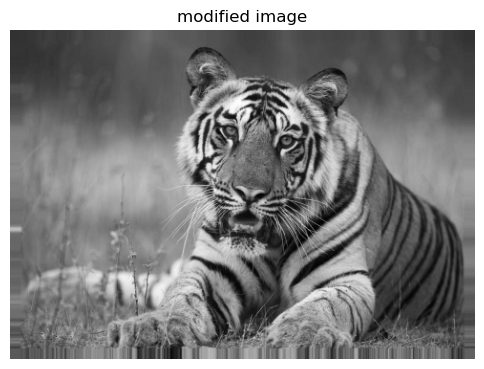

In [6]:
kernel_size = PATCH_SIZE // 2

# Duplicate the first row 10 times and add them above the image
first_row = resized_image[0:1, :]
above_rows = np.tile(first_row, (kernel_size, 1))
img = np.vstack([above_rows, resized_image])

# Duplicate the last row 10 times and add them below the image
last_row = img[-1:, :]
below_rows = np.tile(last_row, (kernel_size, 1))
img = np.vstack([img, below_rows])

# Duplicate the first column 10 times on the left side
left_columns = np.tile(img[:, 0:1], (1, kernel_size))
image = np.concatenate((left_columns, img), axis=1)

# Duplicate the last column 10 times on the right side
right_columns = np.tile(image[:, -1:], (1, kernel_size))
image = np.concatenate((image, right_columns), axis=1)

# Displaying the modified image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray') 
plt.title(f"modified image")
plt.axis('off')
plt.show()

window_shape = (PATCH_SIZE, PATCH_SIZE)
patches = view_as_windows(image, window_shape)

# Number of processes
nprocs = 2 

# Function to compute GLCM properties for a given patch
def compute_glcm_properties(patch):
    glcm = graycomatrix(patch, distances=[5], angles=[0], levels=256,
                        symmetric=True, normed=True)
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0] 
    return dissimilarity, correlation, homogeneity, energy

# Running compute_glcm_properties in parallel 
result = Parallel(n_jobs=nprocs)(
    delayed(compute_glcm_properties)(patches[i, j]) 
    for i in range(patches.shape[0]) 
    for j in range(patches.shape[1])
)

# Separating the result into individual tuples
dissimilarity, correlation, homogeneity, energy = zip(*result)


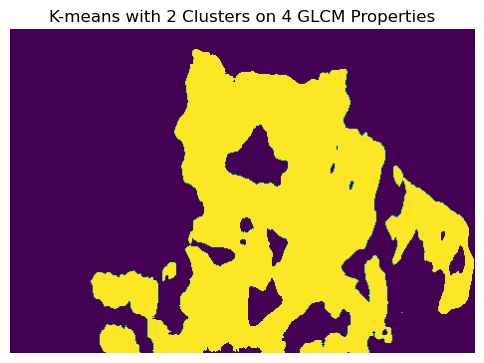

In [7]:
# Converting the GLCM properties to a NumPy array
glcm_properties_array = np.array([dissimilarity, correlation, homogeneity, energy]).T 

# Performing K-means quantization with n_colors=2 on all GLCM properties
n_colors = 2
kmeans = KMeans(n_clusters=n_colors, random_state=0)
kmeans.fit(glcm_properties_array)
labels = kmeans.predict(glcm_properties_array)
quantized_palette = kmeans.cluster_centers_.astype(int)

# Reshaping quantized labels to match the shape of the patches
quantized_labels = labels.reshape(patches.shape[0], patches.shape[1])

# Displaying the quantized image
plt.figure(figsize=(6, 6))
plt.imshow(quantized_labels / (n_colors - 1), cmap='viridis')  # Normalize to [0, 1] for visualization
plt.title(f"K-means with {n_colors} Clusters on 4 GLCM Properties")
plt.axis('off')
plt.show()
